In [1]:
#Step 1- import and load data

# pandas (pd): Data loading
# numpy (np): Numerical operations, arrays, mathematical functions
# matplotlib.pyplot (plt): Basic plotting and visualisation 
# seaborn (sns): Advanced statistical visualisations
# warnings: Suppresses non-critical warning messages to keep output clean

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

base_path = '/kaggle/input/datasets/cjgdev/formula-1-race-data-19502017/'

#loading tables, also using encoding = 'latin-1' for special chars

results = pd.read_csv(base_path + 'results.csv', encoding = 'latin-1')
races = pd.read_csv(base_path + 'races.csv', encoding = 'latin-1')
drivers = pd.read_csv(base_path + 'drivers.csv', encoding = 'latin-1')
constructors = pd.read_csv(base_path + 'constructors.csv', encoding = 'latin-1')
qualifying = pd.read_csv(base_path + 'qualifying.csv', encoding = 'latin-1')
circuits = pd.read_csv(base_path + 'circuits.csv', encoding = 'latin-1')


print(f"Results shape: {results.shape}")
print(f"Races shape: {races.shape}")
print(f"Drivers shape: {drivers.shape}")
print(f"Columns in results: {results.columns.tolist()[:15]}")
results.head(25)

Results shape: (23777, 18)
Races shape: (997, 8)
Drivers shape: (842, 9)
Columns in results: ['resultId', 'raceId', 'driverId', 'constructorId', 'number', 'grid', 'position', 'positionText', 'positionOrder', 'points', 'laps', 'time', 'milliseconds', 'fastestLap', 'rank']


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
0,1,18,1,1,22.0,1,1.0,1,1,10.0,58,34:50.6,5690616.0,39.0,2.0,01:27.5,218.3,1
1,2,18,2,2,3.0,5,2.0,2,2,8.0,58,5.478,5696094.0,41.0,3.0,01:27.7,217.586,1
2,3,18,3,3,7.0,7,3.0,3,3,6.0,58,8.163,5698779.0,41.0,5.0,01:28.1,216.719,1
3,4,18,4,4,5.0,11,4.0,4,4,5.0,58,17.181,5707797.0,58.0,7.0,01:28.6,215.464,1
4,5,18,5,1,23.0,3,5.0,5,5,4.0,58,18.014,5708630.0,43.0,1.0,01:27.4,218.385,1
5,6,18,6,3,8.0,13,6.0,6,6,3.0,57,NaN,NaN,50.0,14.0,01:29.6,212.974,11
6,7,18,7,5,14.0,17,7.0,7,7,2.0,55,NaN,NaN,22.0,12.0,01:29.5,213.224,5
7,8,18,8,6,1.0,15,8.0,8,8,1.0,53,NaN,NaN,20.0,4.0,01:27.9,217.18,5
8,9,18,9,2,4.0,2,NaN,R,9,0.0,47,NaN,NaN,15.0,9.0,01:28.8,215.1,4
9,10,18,10,7,12.0,18,NaN,R,10,0.0,43,NaN,NaN,23.0,13.0,01:29.6,213.166,3


In [2]:
#part 2, clean data, create target 

#remove missing 
results_clean = results.copy()
results_clean = results_clean[results_clean['position'].notna()]
results_clean = results_clean[results_clean['position']!= '\\N'] # remove, where driver DNF
results_clean['position'] = results_clean['position'].astype(int)

results_clean = results_clean[results_clean['position']<= 20]
results_clean['top10']= (results_clean['position']<= 10).astype(int) # make new column if driver finished top-10 -> 1, else -> 0 

print(f"After cleaning: {len(results_clean)} race results")
print(f"Top-10 proportion: {results_clean['top10'].mean():.3f}")
print(f"Position range: {results_clean['position'].min()} to {results_clean['position'].max()}")

results_clean.head(25)


After cleaning: 13154 race results
Top-10 proportion: 0.722
Position range: 1 to 20


,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId,top10
0,1,18,1,1,22.0,1,1,1,1,10.0,58,34:50.6,5690616.0,39.0,2.0,01:27.5,218.3,1,1
1,2,18,2,2,3.0,5,2,2,2,8.0,58,5.478,5696094.0,41.0,3.0,01:27.7,217.586,1,1
2,3,18,3,3,7.0,7,3,3,3,6.0,58,8.163,5698779.0,41.0,5.0,01:28.1,216.719,1,1
3,4,18,4,4,5.0,11,4,4,4,5.0,58,17.181,5707797.0,58.0,7.0,01:28.6,215.464,1,1
4,5,18,5,1,23.0,3,5,5,5,4.0,58,18.014,5708630.0,43.0,1.0,01:27.4,218.385,1,1
5,6,18,6,3,8.0,13,6,6,6,3.0,57,NaN,NaN,50.0,14.0,01:29.6,212.974,11,1
6,7,18,7,5,14.0,17,7,7,7,2.0,55,NaN,NaN,22.0,12.0,01:29.5,213.224,5,1
7,8,18,8,6,1.0,15,8,8,8,1.0,53,NaN,NaN,20.0,4.0,01:27.9,217.18,5,1
22,23,19,8,6,1.0,2,1,1,1,10.0,56,31:18.6,5478555.0,37.0,2.0,01:35.4,209.158,1,1
23,24,19,9,2,4.0,4,2,2,2,8.0,56,19.57,5498125.0,39.0,6.0,01:35.9,208.033,1,1


In [3]:

# STEP 3: Merge with race, driver, constructor info


races_subset = races[['raceId', 'year', 'circuitId']]
data = results_clean.merge(races_subset, on='raceId', how='left')


data = data.merge(drivers[['driverId', 'forename', 'surname']], on='driverId', how='left')


data = data.merge(constructors[['constructorId', 'name']], on='constructorId', how='left')
data.rename(columns={'name': 'constructor_name'}, inplace=True)


data['grid'] = data['grid'].fillna(20).astype(int)

print("\nFirst 5 rows (selected columns):")
print(data[['position', 'top10', 'year', 'circuitId', 'grid', 'forename', 'surname', 'constructor_name']].head())

data.info()
data.isnull().sum()


First 5 rows (selected columns):
   position  top10  year  circuitId  grid  forename     surname  \
0         1      1  2008          1     1     Lewis    Hamilton   
1         2      1  2008          1     5      Nick    Heidfeld   
2         3      1  2008          1     7      Nico     Rosberg   
3         4      1  2008          1    11  Fernando      Alonso   
4         5      1  2008          1     3    Heikki  Kovalainen   

  constructor_name  
0          McLaren  
1       BMW Sauber  
2         Williams  
3          Renault  
4          McLaren  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13154 entries, 0 to 13153
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   resultId          13154 non-null  int64  
 1   raceId            13154 non-null  int64  
 2   driverId          13154 non-null  int64  
 3   constructorId     13154 non-null  int64  
 4   number            13154 non-null  float64

resultId               0
raceId                 0
driverId               0
constructorId          0
number                 0
grid                   0
position               0
positionText           0
positionOrder          0
points                 0
laps                   0
time                7153
milliseconds        7154
fastestLap          8747
rank                8726
fastestLapTime      8747
fastestLapSpeed     8747
statusId               0
top10                  0
year                   0
circuitId              0
forename               0
surname                0
constructor_name       0
dtype: int64

In [4]:
#step 4

constructor_avg = data.groupby(['year','constructorId'])['position'].mean().reset_index()
constructor_avg.rename(columns={'position':'constructor_avg_pos'},inplace=True)
data= data.merge(constructor_avg, on =['year','constructorId'],how='left')

races_order = races[['raceId','year','round']].drop_duplicates()
data= data.merge(races_order, on=['raceId','year'], how = 'left')
data.sort_values(['driverId','year','round'],inplace=True)
data['driver_race_no']= data.groupby('driverId').cumcount()+1

circuit_avg=data.groupby('circuitId')['position'].mean().reset_index()
circuit_avg.rename(columns={'position':'circuit_avg_pos'},inplace = True)
data=data.merge(circuit_avg, on = 'circuitId',how = 'left')

features = ['year','grid','constructor_avg_pos','driver_race_no','circuit_avg_pos']
data=data.dropna(subset=features+['top10','position'])

print(f"After feature engineering: {data.shape[0]} rowns")
print("Features:",features)
print(data[features].head())

After feature engineering: 13154 rowns
Features: ['year', 'grid', 'constructor_avg_pos', 'driver_race_no', 'circuit_avg_pos']
   year  grid  constructor_avg_pos  driver_race_no  circuit_avg_pos
0  2007     4              2.96875               1         7.152174
1  2007     4              2.96875               2         8.462838
2  2007     2              2.96875               3         9.232143
3  2007     4              2.96875               4         8.401961
4  2007     2              2.96875               5         6.493581


In [5]:
#step 5 

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data[features]
y_class = data['top10']
y_reg = data['position']

X_train,X_test, y_train_class,y_test_class,y_train_reg,y_test_reg = train_test_split(
    X,y_class,y_reg,test_size=0.2,random_state=42,stratify=y_class
)

scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")
print(f"Training top-10-rate: {y_train_class.mean():.3f}")
print(f"Test top-10 rate: {y_test_class.mean():.3f}")

Training samples: 10523, Test samples: 2631
Training top-10-rate: 0.722
Test top-10 rate: 0.722


Logistic Regression
Accuracy:0.8278
F1-Score: 0.8849


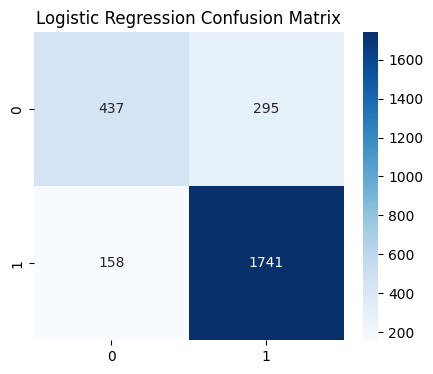

In [6]:
#step 6 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,f1_score,mean_absolute_error,confusion_matrix

lr=LogisticRegression(max_iter=1000,random_state=42)
lr.fit(X_train_scaled, y_train_class)
y_pred_lr=lr.predict(X_test_scaled)

acc_lr=accuracy_score(y_test_class,y_pred_lr)
f1_lr= f1_score(y_test_class,y_pred_lr)

print("Logistic Regression")
print(f"Accuracy:{acc_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_class,y_pred_lr),annot=True,fmt='d',cmap='Blues')
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Random Forest Results
Accuracy: 0.8259
F1-score: 0.8838
MAE (position): 2.1960


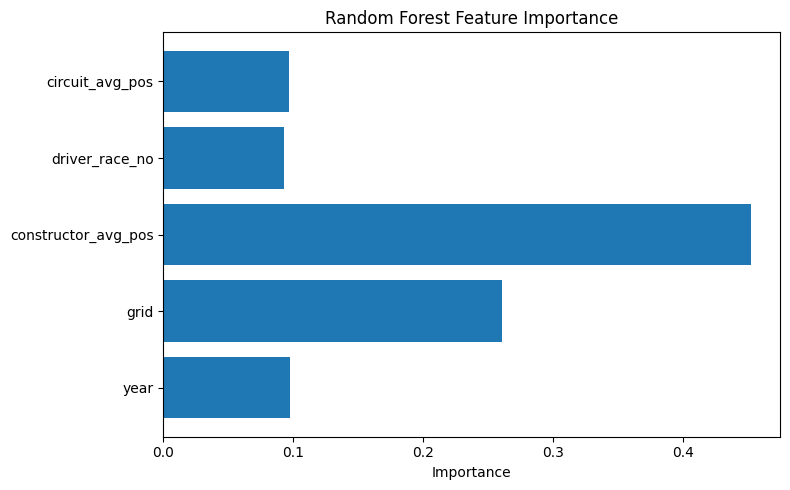

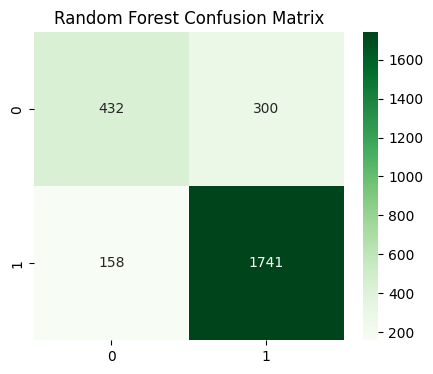

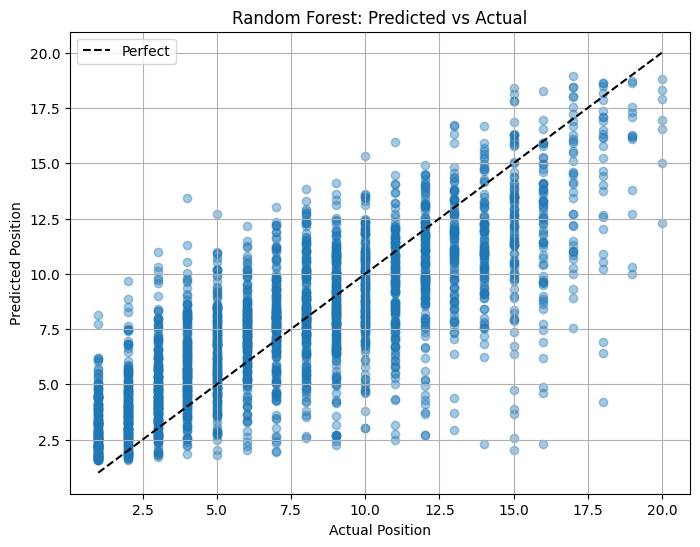

In [7]:
# STEP 7: Random Forest (Ensemble)

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, mean_absolute_error, confusion_matrix

#Classification
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_scaled, y_train_class)   # FIXED: use y_train_class
y_pred_rf_clf = rf_clf.predict(X_test_scaled)

acc_rf = accuracy_score(y_test_class, y_pred_rf_clf)
f1_rf = f1_score(y_test_class, y_pred_rf_clf)

#Regression
rf_reg = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_scaled, y_train_reg)
y_pred_rf_reg = rf_reg.predict(X_test_scaled)
mae_rf = mean_absolute_error(y_test_reg, y_pred_rf_reg)

print("Random Forest Results")
print(f"Accuracy: {acc_rf:.4f}")
print(f"F1-score: {f1_rf:.4f}")
print(f"MAE (position): {mae_rf:.4f}")

importances = rf_clf.feature_importances_
plt.figure(figsize=(8,5))
plt.barh(features, importances)
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_class, y_pred_rf_clf), annot=True, fmt='d', cmap='Greens')
plt.title('Random Forest Confusion Matrix')
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(y_test_reg, y_pred_rf_reg, alpha=0.4)
plt.plot([1,20], [1,20], 'k--', label='Perfect')
plt.xlabel('Actual Position')
plt.ylabel('Predicted Position')
plt.title('Random Forest: Predicted vs Actual')
plt.legend()
plt.grid(True)
plt.show()

2026-07-30 17:07:10.399463: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
ANN (MLP) Classification Results
Accuracy: 0.8331
F1-score: 0.8900


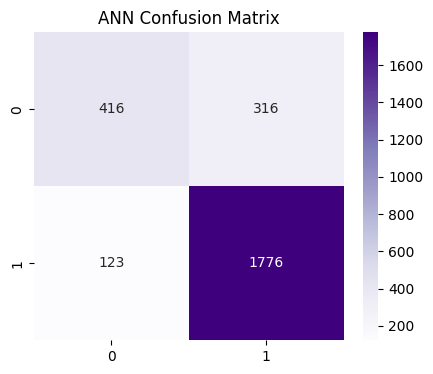

83/83 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
MAE (position regression): 2.2562


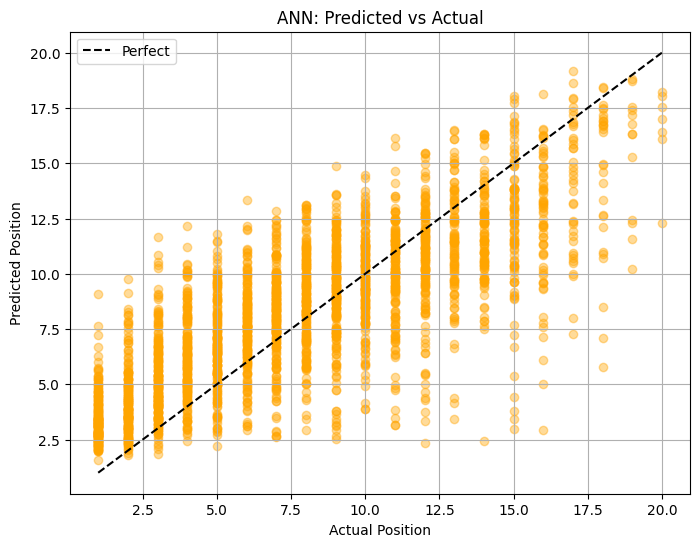

In [8]:
#step 8 - ANN 

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Classification model
ann_clf = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])
ann_clf.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
ann_clf.fit(X_train_scaled, y_train_class, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

y_pred_ann_clf = (ann_clf.predict(X_test_scaled) > 0.5).astype(int)
acc_ann = accuracy_score(y_test_class, y_pred_ann_clf)
f1_ann = f1_score(y_test_class, y_pred_ann_clf)

print("ANN (MLP) Classification Results")
print(f"Accuracy: {acc_ann:.4f}")
print(f"F1-score: {f1_ann:.4f}")

# Confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test_class, y_pred_ann_clf), annot=True, fmt='d', cmap='Purples')
plt.title('ANN Confusion Matrix')
plt.show()

# Regression model for MAE
ann_reg = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])
ann_reg.compile(loss='mean_squared_error', optimizer='adam')
ann_reg.fit(X_train_scaled, y_train_reg, epochs=10, batch_size=32, validation_split=0.2, verbose=0)

y_pred_ann_reg = ann_reg.predict(X_test_scaled).flatten()
mae_ann = mean_absolute_error(y_test_reg, y_pred_ann_reg)
print(f"MAE (position regression): {mae_ann:.4f}")

# Predicted vs actual
plt.figure(figsize=(8,6))
plt.scatter(y_test_reg, y_pred_ann_reg, alpha=0.4, color='orange')
plt.plot([1,20], [1,20], 'k--', label='Perfect')
plt.xlabel('Actual Position')
plt.ylabel('Predicted Position')
plt.title('ANN: Predicted vs Actual')
plt.legend()
plt.grid(True)
plt.show()

In [9]:
#step 9 

from sklearn.linear_model import LinearRegression


lr_reg = LinearRegression()
lr_reg.fit(X_train_scaled, y_train_reg)
y_pred_lr_reg = lr_reg.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr_reg)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression (baseline)', 'Random Forest (ensemble)', 'ANN (MLP – class example)'],
    'Accuracy': [acc_lr, acc_rf, acc_ann],
    'F1-score': [f1_lr, f1_rf, f1_ann],
    'MAE (position)': [mae_lr, mae_rf, mae_ann]
})

print("\n" + "="*60)
print("="*60)
print(comparison.to_string(index=False))
print("="*60)


                         Model  Accuracy  F1-score  MAE (position)
Logistic Regression (baseline)  0.827822  0.884879        2.194808
      Random Forest (ensemble)  0.825922  0.883756        2.196031
     ANN (MLP – class example)  0.833143  0.890003        2.256204


In [10]:
#step 10 error analysis
errors = X_test.copy()
errors['true'] = y_test_class
errors['pred'] = y_pred_rf_clf
errors['error'] = errors['true'] != errors['pred']
errors['actual_position'] = y_test_reg.values
errors['grid'] = X_test['grid'].values
errors['driver'] = data.loc[X_test.index, 'forename'] + " " + data.loc[X_test.index, 'surname']
errors['year'] = data.loc[X_test.index, 'year']
errors['constructor'] = data.loc[X_test.index, 'constructor_name']

mis = errors[errors['error']]
print(f"Total misclassifications: {len(mis)} / {len(X_test)} ({100*len(mis)/len(X_test):.2f}%)")
print("\nFirst 10 misclassified examples:")
print(mis[['driver', 'year', 'constructor', 'actual_position', 'grid']].head(10))

fp = mis[(mis['true']==0) & (mis['pred']==1)]
print(f"\nFalse positives: {len(fp)}")
print(fp[['driver', 'year', 'actual_position', 'grid']].head())

unusual = mis[(mis['grid'] <= 5) & (mis['actual_position'] >= 15)]
print(f"\nUnusual events (grid ≤5, finish ≥15): {len(unusual)}")
print(unusual[['driver', 'year', 'constructor', 'actual_position', 'grid']].head())

Total misclassifications: 458 / 2631 (17.41%)

First 10 misclassified examples:
                   driver  year   constructor  actual_position  grid
10850            Jim Hall  1963     Lotus-BRM               11    18
10974       Hans Herrmann  1958      Maserati                9    18
9497          Graham Hill  1974          Lola                8    21
11761      Yves Cabantous  1953           HWM               14    18
9432          Graham Hill  1964           BRM               11     6
3506   Juan Pablo Montoya  2005       McLaren               14     1
11157         Jimmy Bryan  1960       Epperly               19    10
4159           Jean Alesi  1990       Tyrrell               11     8
3806   Cristiano da Matta  2003        Toyota               10    18
7002      Romain Grosjean  2017  Haas F1 Team               10    14

False positives: 300
                   driver  year  actual_position  grid
10850            Jim Hall  1963               11    18
11761      Yves Cabantous  19

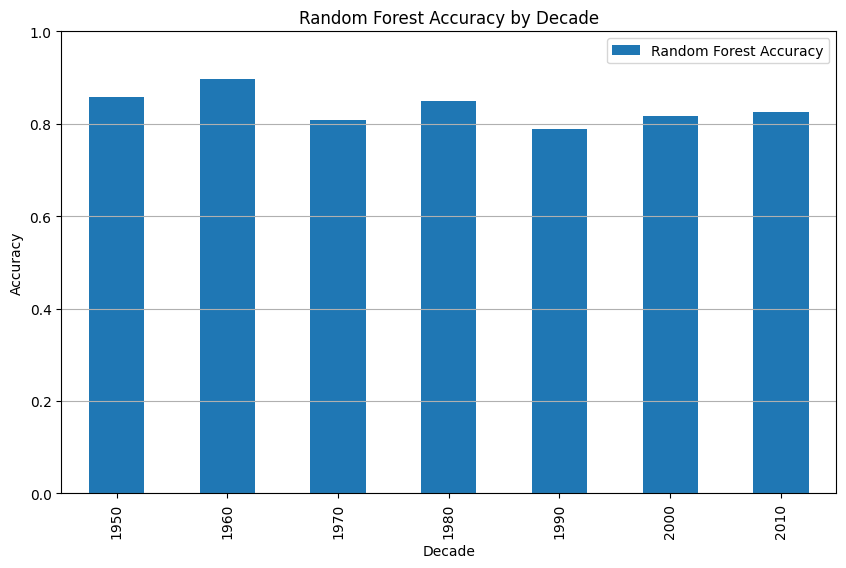

In [11]:
#step 11
data['decade'] = (data['year'] // 10) * 10
test_indices = X_test.index
test_decade = data.loc[test_indices, 'decade']

decades = sorted(test_decade.unique())
decade_acc = []

for d in decades:
    mask = test_decade == d
    if mask.sum() > 5:
        acc = accuracy_score(y_test_class[mask], y_pred_rf_clf[mask])
        decade_acc.append((d, acc))

df_decade = pd.DataFrame(decade_acc, columns=['Decade', 'Random Forest Accuracy'])
df_decade.set_index('Decade', inplace=True)

df_decade.plot(kind='bar', figsize=(10,6))
plt.title('Random Forest Accuracy by Decade')
plt.xlabel('Decade')
plt.ylabel('Accuracy')
plt.ylim(0,1)
plt.grid(axis='y')
plt.show()